# Structural Properties

This notebook uses a model implementation based on Xie's XGI-based implementation, with object-oriented design and some optimizations for speed. The purpose is to theoretical predictions for some structural properties of the model, especially the degree distribution. 

In [1]:
import importlib 
m = importlib.import_module(".model", "src")
from matplotlib import pyplot as plt
import numpy as np

### Model Parameters

In [2]:
eta = 0.5
gamma = 1.0
beta = 0.1
force_one_node = True

### Predictions from Theory

In our notes, we informally derived the mean edge size $\langle k \rangle$, mean degree $\langle d \rangle$, and power law exponent $\delta$ for the model variant in which each edge always inherits at least one node from its parent edge. For the edge size and degrees, we found: 

$$
\begin{align}
    \langle k \rangle &= 1 + \frac{\gamma + \beta}{1 - \eta} \\ 
    \langle d \rangle &= \beta^{-1}\langle k \rangle\;. 
\end{align}
$$

The exponent $\delta$ is given by 

$$
\delta = -\left(1 + \frac{\beta}{a}\right)\;,
$$

where 
$$
a = \frac{1 + \eta(\langle k \rangle - 1)}{\langle d \rangle}\;.
$$

The function below forms these predictions: 

In [3]:
def predictions(eta, gamma, beta, force_one_node = False):
    if not force_one_node:
        return -(eta+1)/eta 
    else:
        mean_k = 1 + (gamma + beta)/(1-eta)
        mean_d = mean_k / beta 
        a      = (1 + eta*(mean_k - 1))/mean_d 
        delta  = - (1 + beta / a)
        return mean_k, mean_d, delta

The predictions for this set of parameters are: 

In [4]:
mean_k, mean_d, delta = predictions(eta, gamma, beta, force_one_node)
mean_k, mean_d, delta

(3.2, 32.0, -2.5238095238095237)

### Experiment 

Let's go ahead and run a model: 

In [5]:
timesteps = int(1e6)

H = m.GrowingHypergraph()
H.add_edge((0, 1))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, force_one_node = force_one_node)

The predicted mean edge size and mean degree agree well with the experiment. 

In [6]:
true_mean_k = H.edge_size_sequence().mean()
true_mean_d = H.degree_sequence().mean()

print(f"Mean edge size:      predicted =  {true_mean_k:1f}  | actual = {mean_k:1f}")
print(f"Mean degree:         predicted =  {true_mean_d:1f}  | actual = {mean_d:1f}")

Mean edge size:      predicted =  3.187377  | actual = 3.200000
Mean degree:         predicted =  31.503944  | actual = 32.000000


Let's check the predicted power law exponent: 

/tmp/ipykernel_27467/3562859813.py:7: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(c.min()/H.H.num_nodes, (c.max()+10000)/H.H.num_nodes)


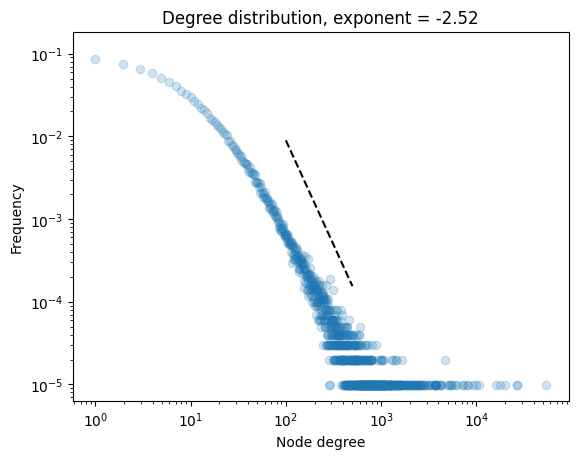

In [7]:
degs = H.degree_sequence()
c, b = np.histogram(degs, bins = 1000000)
fig, ax = plt.subplots(1, 1)

ax.scatter(b[:-1], c/H.H.num_nodes, alpha = 0.2)
ax.loglog()
ax.set_ylim(c.min()/H.H.num_nodes, (c.max()+10000)/H.H.num_nodes)

x = np.linspace(100, 500)
y = 1000*x**delta

ax.plot(x, y, color = "black", linestyle = "dashed")

labs = ax.set(xlabel = "Node degree", ylabel = "Frequency", title = f"Degree distribution, exponent = {round(delta, 2)}")

plt.savefig("../fig/degree-distribution-experiment.png", dpi = 300)

It's a little hard to reliably eyeball these exponents, but by eye the result looks pretty good! 